# Optimizing Dynamic Pricing in EV Networks
## A Hybrid Framework using Volatility Clustering (GARCH) and Deep Time-Series Forecasting (N-BEATS/LSTM)

**Dataset:** EV Charging Station Availability Tracking
**Size:** ~1.3M Records | 150 Stations | 6 Months | 30-minute granularity

---
### Overview:
Part 1: FFT/Spectral Analysis -  Detect daily & weekly cycles\
Part 2: SARIMAX - Classical baseline with exogenous regressors\
Part 3: GARCH(1,1) - Volatility clustering → dynamic pricing trigger\
Part 4: N-BEATS / LSTM -  Deep learning for non-linear demand surges

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {'actual': '#2196F3', 'sarima': '#FF9800', 'nbeats': '#4CAF50', 'garch': '#E91E63'}

#### Data Loading & Preprocessing

In [3]:
df = pd.read_csv('ev_charging_station_data.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df.timestamp.min()} → {df.timestamp.max()}')
print(f'Stations      : {df.station_id.nunique() if "station_id" in df.columns else "N/A"}')
df.head()

Dataset shape : (1317750, 33)
Date range    : 2025-07-01 00:00:00 → 2025-12-31 00:00:00
Stations      : 150


,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-07-01,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,5.08,2,none,False,False,0,1,7
1,2025-07-01,EV00094,Tesla Supercharger - Seattle #14,Tesla Supercharger,Seattle,WA,47.467953,-122.304267,Highway Corridor,Tesla DC Fast,...,0.0,clear,4.24,1,none,False,False,0,1,7
2,2025-07-01,EV00131,Electrify America - Phoenix #11,Electrify America,Phoenix,AZ,33.509449,-112.059171,Airport,DC Fast Charge,...,0.0,extreme_heat,3.59,2,none,False,False,0,1,7
3,2025-07-01,EV00054,Volta - Miami #14,Volta,Miami,FL,25.658489,-80.070434,Airport,Level 2,...,0.0,extreme_heat,3.38,3,none,False,False,0,1,7
4,2025-07-01,EV00079,ChargePoint - Seattle #19,ChargePoint,Seattle,WA,47.646867,-122.454396,Airport,Level 2,...,4.0,light_rain,4.21,2,sports_game,False,False,0,1,7


In [4]:
# Network-level aggregate where we consider mean of all stations
ts = (
    df.groupby('timestamp')
    .agg(
        utilization_rate=('utilization_rate', 'mean'),
        ports_occupied  =('ports_occupied',   'sum'),
        temperature_f   =('temperature_f',    'mean'),
        precipitation_mm=('precipitation_mm', 'mean'),
        current_price   =('current_price',    'mean'),
        is_weekend      =('is_weekend',       'first'),
    )
    .reset_index()
    .set_index('timestamp')
    .asfreq('30T')              # enforce 30-minute frequency
)

# forward fill for nulls
ts = ts.ffill()

print(f'Time-series shape after aggregation: {ts.shape}')
ts.describe()

Time-series shape after aggregation: (8785, 6)


,utilization_rate,ports_occupied,temperature_f,precipitation_mm,current_price
count,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000
mean,0.416167,359.062948,71.674259,0.582298,0.313656
std,0.227674,226.015763,16.881104,0.235629,0.029697
min,0.063200,8.000000,47.962000,0.074667,0.263060
25%,0.165220,109.000000,50.142000,0.408667,0.309467
50%,0.512113,447.000000,86.061333,0.550000,0.312640
75%,0.612900,558.000000,87.400000,0.722667,0.318607
max,0.763993,714.000000,89.366000,1.672667,0.372733


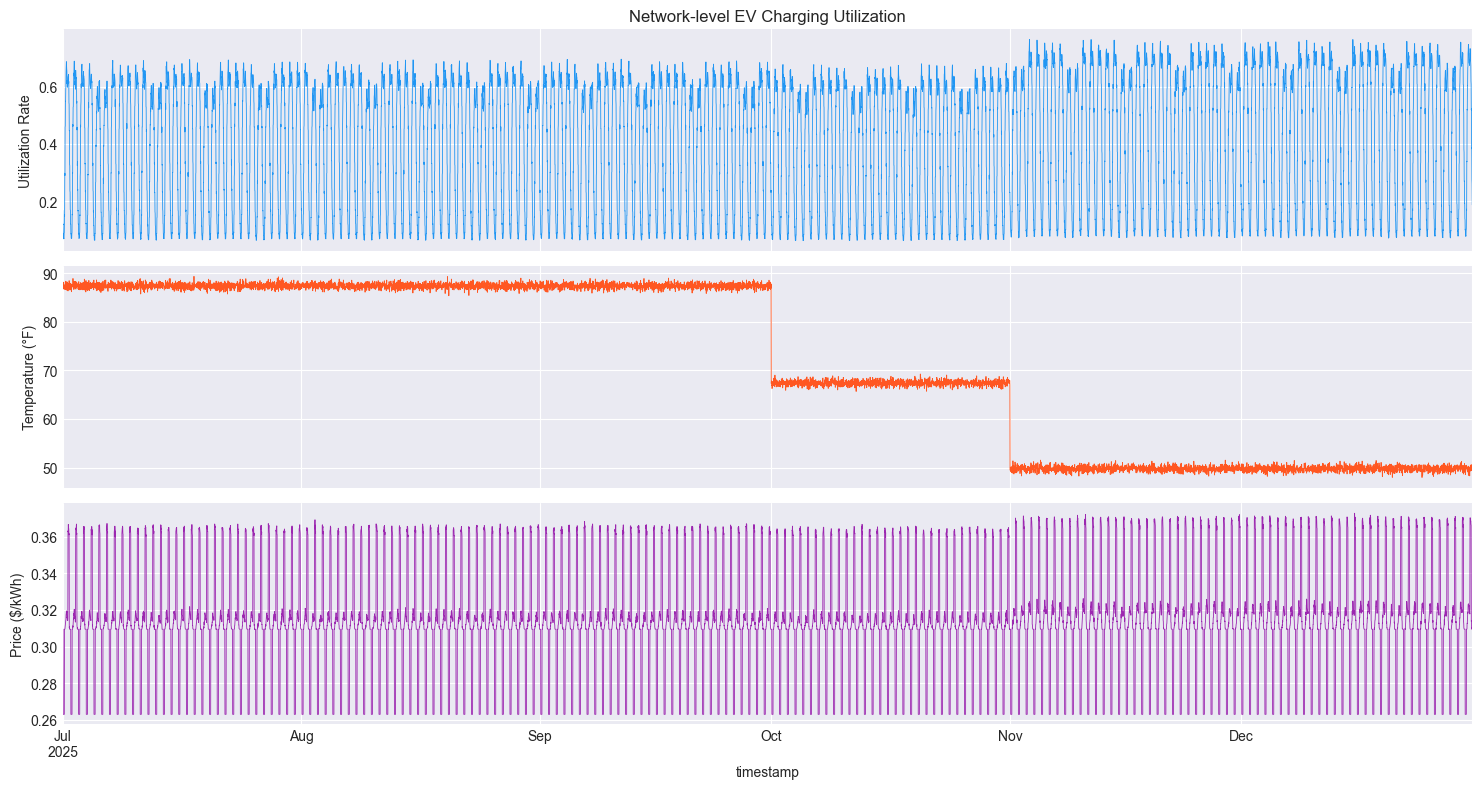

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

ts['utilization_rate'].plot(ax=axes[0], color=COLORS['actual'], linewidth=0.6)
axes[0].set_ylabel('Utilization Rate'); axes[0].set_title('Network-level EV Charging Utilization')

ts['temperature_f'].plot(ax=axes[1], color='#FF5722', linewidth=0.6)
axes[1].set_ylabel('Temperature (°F)')

ts['current_price'].plot(ax=axes[2], color='#9C27B0', linewidth=0.6)
axes[2].set_ylabel('Price ($/kWh)')

plt.tight_layout()
plt.savefig('fig0_overview.png', dpi=150, bbox_inches='tight')
plt.show()

For utilization rate - it is evident that there are seasonal patterns visible and change in trend post november as winter approaches.

For temperature - it is an external factor - drops in Oct and November. As Temperature drops, utilization and price start increasing. This implies that weather is a major driver of charging behavior. EV batteries are less efficient in the cold, potentially requiring increased/frequent charging

For price - cost/kilowatt-hour that is charged to customer follows a rhythmic pattern, increases in november, much like utilization.

#### Spectral Analysis & Seasonal Decomposition
To prove htat data is predictable

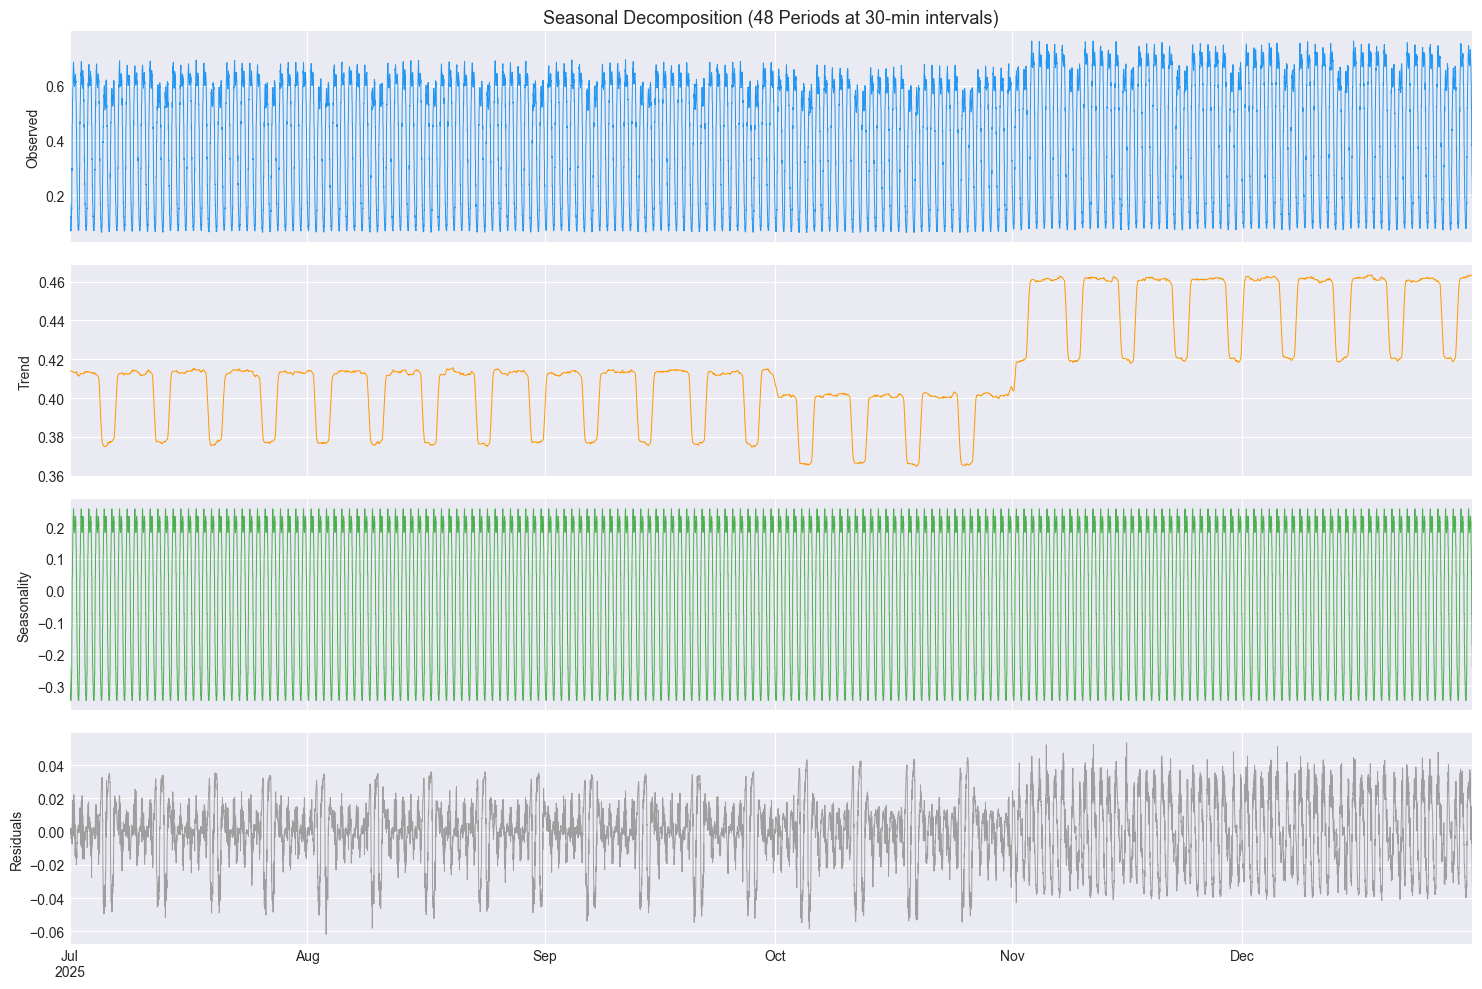

In [5]:
# Seasonal Decomposition
# Period = 48 half-hours
decomp = seasonal_decompose(ts['utilization_rate'], model='additive', period=48, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
panels = [
    (decomp.observed,  'Observed',   COLORS['actual']),
    (decomp.trend,     'Trend',      '#FF9800'),
    (decomp.seasonal,  'Seasonality','#4CAF50'),
    (decomp.resid,     'Residuals',  '#9E9E9E'),
]
for ax, (series, label, color) in zip(axes, panels):
    series.plot(ax=ax, color=color, linewidth=0.7)
    ax.set_ylabel(label)
    ax.set_xlabel('')

axes[0].set_title('Seasonal Decomposition (48 Periods at 30-min intervals)', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

On the whole there is a shift in demand in November.

The trend smoothens out the noise and shows the direction of data in the long run. In november, there is a step up showing increasing utilization. Colder weather creates a higher permanent demand for charging.

The seasonality captures repeating patterns, there are daily rush hours when utilization is higher than the average.

The noise becomes larger in November and December. This means that unexplained noise increases in the winter months, demand becomes less stable.

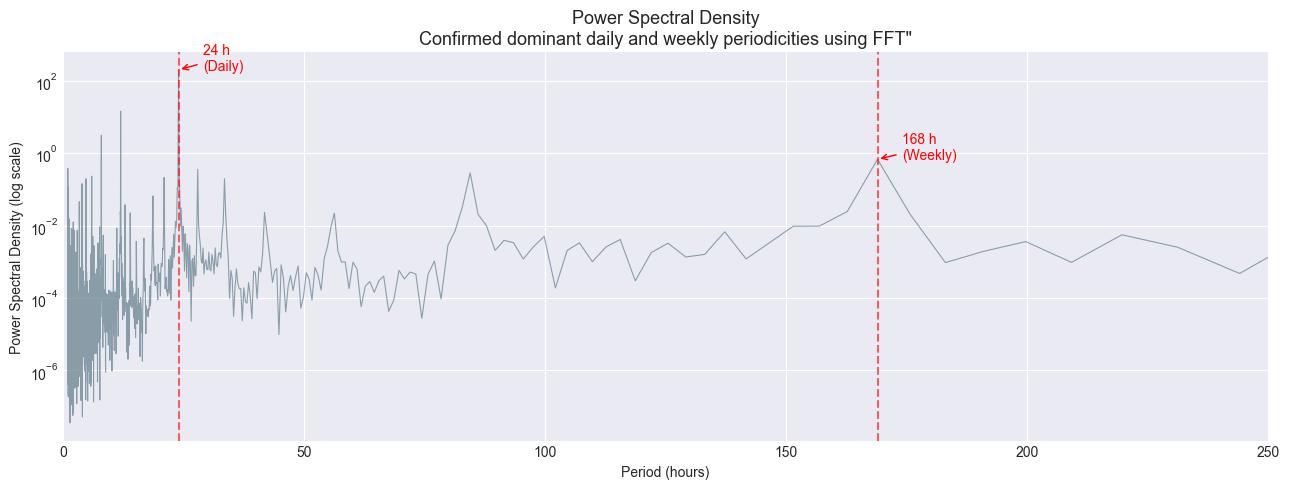

In [6]:
# FFT — Power Spectral Density
signal = ts['utilization_rate'].dropna().values
n= len(signal)
fs=2.0          # samples per hour (30-min intervals)

freqs, power = periodogram(signal, fs=fs)

# Convert frequency period to hours
periods = np.where(freqs > 0, 1.0 / freqs, np.inf)

fig, ax = plt.subplots(figsize=(13, 5))
ax.semilogy(periods, power, color='#607D8B', linewidth=0.8, alpha=0.7)

# Highlight dominant peaks
for period_h, label in [(24, '24 h\n(Daily)'), (168, '168 h\n(Weekly)')]:
    mask = np.abs(periods - period_h) < 2
    if mask.any():
        peak_idx = np.argmax(power[mask])
        px = periods[mask][peak_idx]
        py = power[mask][peak_idx]
        ax.axvline(px, color='red', linestyle='--', alpha=0.6)
        ax.annotate(label, xy=(px, py), xytext=(px + 5, py),
                    fontsize=10, color='red',
                    arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlim(0, 250)
ax.set_xlabel('Period (hours)')
ax.set_ylabel('Power Spectral Density (log scale)')
ax.set_title('Power Spectral Density\nConfirmed dominant daily and weekly periodicities using FFT"', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_psd.png', dpi=150, bbox_inches='tight')
plt.show()

Periodicity is the highest daily and weekly

Dominant cycles are at 24hrs and 168hrs, justifying SARIMAX

In [7]:
# ADF Stationarity Test
adf_result = adfuller(ts['utilization_rate'].dropna())
print('ADF Stationarity Test')
print(f'  Test Statistic : {adf_result[0]:.4f}')
print(f'  p-value        : {adf_result[1]:.6f}')
print(f'  Critical Values: {adf_result[4]}')
conclusion = 'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY — differencing required'
print(f'  Conclusion     : {conclusion}')

ADF Stationarity Test
  Test Statistic : -10.7443
  p-value        : 0.000000
  Critical Values: {'1%': np.float64(-3.43109782440793), '5%': np.float64(-2.8618704886904087), '10%': np.float64(-2.5669459141578455)}
  Conclusion     : STATIONARY


ADF test results show that the data is stationary and the mean-reverting nature of daily cycles is strong enough that the data can be treated as stationary.

---
### Classical Baseline: Seasonal Naive

In [9]:
# Test split: last 2 weeks
TEST_PERIODS = 48 * 14   # 14 days × 48 half-hours

train = ts.iloc[:-TEST_PERIODS]
test  = ts.iloc[-TEST_PERIODS:]

print(f'Train : {train.index[0]} → {train.index[-1]}  ({len(train):,} obs)')
print(f'Test  : {test.index[0]}  → {test.index[-1]}   ({len(test):,} obs)')

Train : 2025-07-01 00:00:00 → 2025-12-17 00:00:00  (8,113 obs)
Test  : 2025-12-17 00:30:00  → 2025-12-31 00:00:00   (672 obs)


In [10]:
# Predicts each value as the value from exactly 1 season ago (48 intervals = 1 day)
SEASON_LENGTH = 48  # 30-min intervals in one day

# For each data point, we check for 48 steps into a combined series
full_series = ts['utilization_rate']
test_start_idx = full_series.index.get_loc(test.index[0])

naive_pred = pd.Series(
    [full_series.iloc[test_start_idx + i - SEASON_LENGTH] for i in range(len(test))],
    index=test.index,
    name='seasonal_naive'
)

naive_mae  = mean_absolute_error(test['utilization_rate'], naive_pred)
naive_mape = np.mean(np.abs((test['utilization_rate'] - naive_pred) / test['utilization_rate'])) * 100

print(f'Seasonal Naive  MAE  : {naive_mae:.4f}')
print(f'Seasonal Naive  MAPE : {naive_mape:.2f}%')

Seasonal Naive  MAE  : 0.0160
Seasonal Naive  MAPE : 3.37%


The low error rate proves that your EV network has very rigid, predictable daily rhythm. People tend to charge their cars at the same time every day. The baseline is very strong to beat.

---
### Sarimax
> *Exogenous variables: `temperature_f`, `is_weekend`*

In [11]:
# Test split: last 2 weeks
TEST_PERIODS = 48 * 14   # 14 days × 48 half-hours

train = ts.iloc[:-TEST_PERIODS]
test  = ts.iloc[-TEST_PERIODS:]

print(f'Train : {train.index[0]} → {train.index[-1]}  ({len(train):,} obs)')
print(f'Test  : {test.index[0]}  → {test.index[-1]}   ({len(test):,} obs)')

Train : 2025-07-01 00:00:00 → 2025-12-17 00:00:00  (8,113 obs)
Test  : 2025-12-17 00:30:00  → 2025-12-31 00:00:00   (672 obs)


In [12]:
# numeric endog
train_endog = pd.to_numeric(train['utilization_rate'], errors='coerce')
test_endog  = pd.to_numeric(test['utilization_rate'],  errors='coerce')

# numeric exog
exog_cols = ['temperature_f', 'is_weekend']

exog_train = train[exog_cols].copy()
exog_test  = test[exog_cols].copy()

# Convert weekend to 0/1 robustly (handles bool, "True"/"False", "Yes"/"No", etc.)
def weekend_to_int(s):
    if s.dtype == bool:
        return s.astype(int)
    s2 = s.astype(str).str.strip().str.lower()
    return s2.map({'true': 1, 'false': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0}).astype(float)

exog_train['is_weekend'] = weekend_to_int(exog_train['is_weekend'])
exog_test['is_weekend']  = weekend_to_int(exog_test['is_weekend'])

# Temperature to numeric
exog_train['temperature_f'] = pd.to_numeric(exog_train['temperature_f'], errors='coerce')
exog_test['temperature_f']  = pd.to_numeric(exog_test['temperature_f'],  errors='coerce')

# Dropping NAs and aligning indices
common_idx_train = train_endog.index.intersection(exog_train.index)
train_endog = train_endog.loc[common_idx_train]
exog_train  = exog_train.loc[common_idx_train]

mask = train_endog.notna() & exog_train.notna().all(axis=1)
train_endog = train_endog.loc[mask]
exog_train  = exog_train.loc[mask]

# same cleanup for test if you want to forecast with exog
common_idx_test = test_endog.index.intersection(exog_test.index)
test_endog = test_endog.loc[common_idx_test]
exog_test  = exog_test.loc[common_idx_test]

mask_t = test_endog.notna() & exog_test.notna().all(axis=1)
test_endog = test_endog.loc[mask_t]
exog_test  = exog_test.loc[mask_t]

In [13]:
sarimax_model = SARIMAX(
    train_endog,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 48),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax_model.fit(disp=False, maxiter=100)
print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   utilization_rate   No. Observations:                 8113
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 48)   Log Likelihood               27010.365
Date:                            Tue, 03 Mar 2026   AIC                         -54006.730
Time:                                    15:56:04   BIC                         -53957.807
Sample:                                07-01-2025   HQIC                        -53989.986
                                     - 12-17-2025                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
temperature_f     0.0001      0.000      1.203      0.229    -8.2e-05       0.000
is_weekend       -0.0047  

There is a statistically significant drop in utilization during the weekends compared to weekdays. The network is primarily driven by commuters and any pricing strategy will be more effective if implied mondays to fridays than weekends.

Temperature is not statistically significant and doesn't alone explain the hour-to-hour changes in charging as well as the time of day or day of the week does.

The network's behavior is so repetitive that yesterday's data is the single best predictor for today.

SARIMAX assumes a normal distribution (Kurtosis of 3.0). Because station data is spiky, SARIMAX tries to smooth everything out, which is why it ended up with a 538% error when trying to predict those individual station bursts. It is not built to handle these shocks.

In [14]:
print(exog_train.dtypes)
print(exog_train['is_weekend'].head(10))
print(exog_train['is_weekend'].unique()[:10])

temperature_f    float64
is_weekend         int64
dtype: object
timestamp
2025-07-01 00:00:00    0
2025-07-01 00:30:00    0
2025-07-01 01:00:00    0
2025-07-01 01:30:00    0
2025-07-01 02:00:00    0
2025-07-01 02:30:00    0
2025-07-01 03:00:00    0
2025-07-01 03:30:00    0
2025-07-01 04:00:00    0
2025-07-01 04:30:00    0
Freq: 30min, Name: is_weekend, dtype: int64
[0 1]


In [15]:
#Forecasting SARIMAX
sarima_pred = sarimax_fit.forecast(steps=len(test), exog=exog_test)
sarima_pred.index = test.index

sarima_mae  = mean_absolute_error(test['utilization_rate'], sarima_pred)
sarima_mape = np.mean(np.abs((test['utilization_rate'] - sarima_pred) / test['utilization_rate'])) * 100

print(f'SARIMAX  MAE  : {sarima_mae:.4f}')
print(f'SARIMAX  MAPE : {sarima_mape:.2f}%')

SARIMAX  MAE  : 0.0173
SARIMAX  MAPE : 3.33%


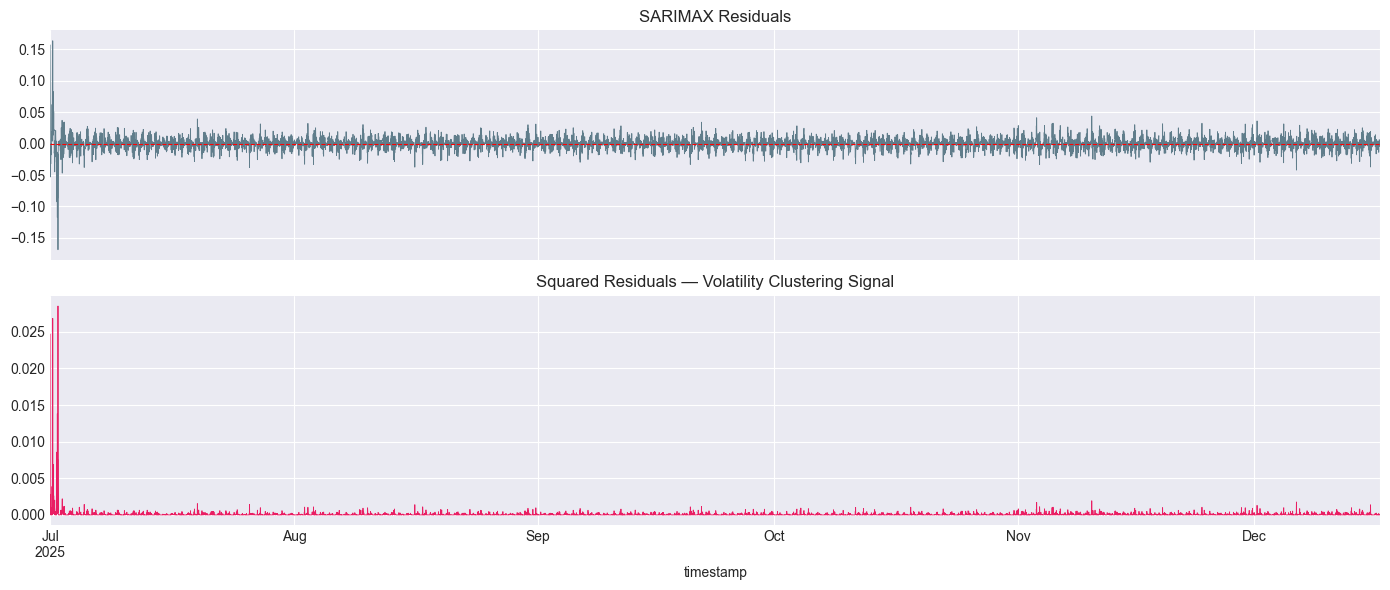

→ Clustering in squared residuals confirms ARCH effects — GARCH modeling warranted.


In [16]:
# Residual plotting for GARCH
sarima_residuals = sarimax_fit.resid

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
sarima_residuals.plot(ax=axes[0], color='#607D8B', linewidth=0.6)
axes[0].set_title('SARIMAX Residuals')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)

(sarima_residuals**2).plot(ax=axes[1], color=COLORS['garch'], linewidth=0.6)
axes[1].set_title('Squared Residuals — Volatility Clustering Signal')

plt.tight_layout()
plt.savefig('fig3_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Clustering in squared residuals confirms ARCH effects — GARCH modeling warranted.')

The SARIMAX model confirms that Weekends are a significant negative driver, while Temperature acts as a baseline shifter but doesn't explain daily spikes.

Squared Residuals plot shows Volatility Clustering. it means that shocks to the system come in waves rather than random blips.

---
## Phase III — Modeling Uncertainty: GARCH(1,1)
> *Output: **Volatility Score** that dictates when Dynamic Pricing should be triggered*

In [17]:
# ── GARCH(1,1) on SARIMAX residuals ──────────────────────────────────────────
# Scale residuals for numerical stability
resid_scaled = sarima_residuals * 100

garch_spec = arch_model(resid_scaled, vol='Garch', p=1, q=1, dist='normal')
garch_fit  = garch_spec.fit(disp='off')
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -9653.12
Distribution:                  Normal   AIC:                           19314.2
Method:            Maximum Likelihood   BIC:                           19342.2
                                        No. Observations:                 8113
Date:                Tue, Mar 03 2026   Df Residuals:                     8112
Time:                        16:12:34   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.8475e-03  6.771e-03     -0.273      0.

GARCH(1,1) will help us to measure risk in the EV charging network. It predicts how unstable demand is at any given moment. The omega tells the minimum amount of unpredicted movement the station has, even during calm periods. The alpha tells how the stations react to suddent unexpected events. Beta measures how long the stress/crowds last. A high beta would imply that if the station gets busy, it is likely to stay busy for a long time. 

GARCH tells us that the station is stable, any chaod eventually settles down and returns to normal. if the sum of alpha and beta was greater than 1, it would mean that the station's usage patterns were becoming unpredictable and unstable.

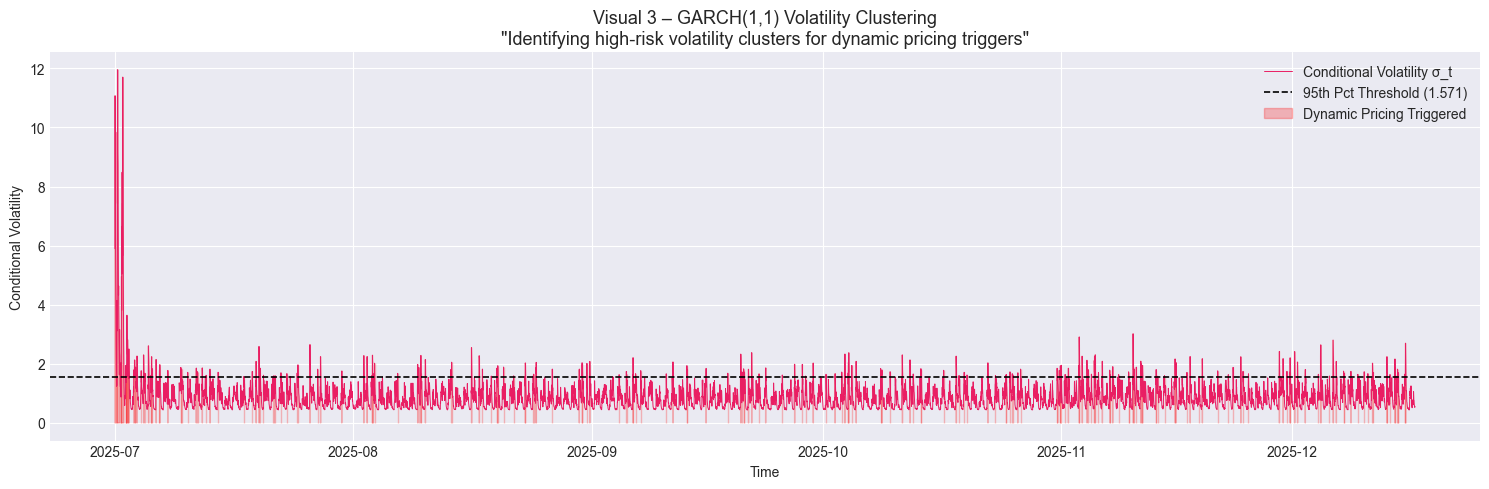

Dynamic pricing would be triggered 5.0% of the time.


In [18]:
# ── Extract Conditional Variance (Volatility Score) ───────────────────────────
cond_vol = garch_fit.conditional_volatility  # σ_t
cond_vol.index = sarima_residuals.index

# Define dynamic pricing trigger threshold (95th percentile)
VOL_THRESHOLD = cond_vol.quantile(0.95)
pricing_trigger = cond_vol > VOL_THRESHOLD

# ── Visual 3: Volatility Clustering Plot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(cond_vol.index, cond_vol.values, color=COLORS['garch'], linewidth=0.7, label='Conditional Volatility σ_t')
ax.axhline(VOL_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'95th Pct Threshold ({VOL_THRESHOLD:.3f})')
ax.fill_between(cond_vol.index, 0, cond_vol.values,
                where=pricing_trigger, color='red', alpha=0.25, label='Dynamic Pricing Triggered')

ax.set_xlabel('Time')
ax.set_ylabel('Conditional Volatility')
ax.set_title('Visual 3 – GARCH(1,1) Volatility Clustering\n'
             '"Identifying high-risk volatility clusters for dynamic pricing triggers"', fontsize=13)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig4_garch_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

trigger_pct = pricing_trigger.mean() * 100
print(f'Dynamic pricing would be triggered {trigger_pct:.1f}% of the time.')

GARCH predicts uncertainty and risk, which you are using to trigger your dynamic pricing. 
It suggests that stations are very sensitive to shocks if a large group of EVs arrives unexpectedly, the system's stress level jumps up instantly.

A value of 0.55 means that once your stations get busy and chaotic, they tend to stay that way for a while.
The network is stable but highly persistent. Because the sum of alpha+beta is so close to 1.0, it says that shocks to the system take a long time to die down.

Approach:
Any time the pink line spikes above that dashed black line, the system automatically triggers surge pricing. We capture the top 5% of most chaotic, high-demand moments to maximize revenue and manage stall turnover.

In [44]:
garch_forecast = garch_fit.forecast(horizon=48)
future_vol = np.sqrt(garch_forecast.variance.values[-1])

In [46]:
ts_sim = ts.copy()

# Align to ts_sim index
vol_aligned = cond_vol.reindex(ts_sim.index)
trigger_aligned = pricing_trigger.reindex(ts_sim.index).fillna(False)

ts_sim['volatility_score'] = vol_aligned
ts_sim['pricing_trigger']  = trigger_aligned

ts_sim['dynamic_price'] = ts_sim['current_price']  # default
ts_sim.loc[ts_sim['pricing_trigger'], 'dynamic_price'] = (
    ts_sim.loc[ts_sim['pricing_trigger'], 'current_price'] * SURGE_MULTIPLIER
)

In [47]:
common_idx = ts.index.intersection(cond_vol.index)

ts_sim = ts.loc[common_idx].copy()
ts_sim['volatility_score'] = cond_vol.loc[common_idx]
ts_sim['pricing_trigger']  = pricing_trigger.loc[common_idx]

ts_sim['dynamic_price'] = np.where(
    ts_sim['pricing_trigger'].values,
    ts_sim['current_price'].values * SURGE_MULTIPLIER,
    ts_sim['current_price'].values
)

In [48]:
print("ts length:", len(ts))
print("cond_vol length:", len(cond_vol))
print("overlap:", len(ts.index.intersection(cond_vol.index)))
print("ts start/end:", ts.index.min(), ts.index.max())
print("vol start/end:", cond_vol.index.min(), cond_vol.index.max())

ts length: 8785
cond_vol length: 8113
overlap: 8113
ts start/end: 2025-07-01 00:00:00 2025-12-31 00:00:00
vol start/end: 2025-07-01 00:00:00 2025-12-17 00:00:00


In [49]:
ts_sim['revenue_static']  = ts_sim['current_price'] * ts_sim['ports_occupied']
ts_sim['revenue_dynamic'] = ts_sim['dynamic_price'] * ts_sim['ports_occupied']

---
## Phase IV — Deep Learning: N-BEATS
> *Handles non-linear demand shocks better than SARIMA via doubly residual learning blocks*

In [50]:
# ── N-BEATS via Darts library ─────────────────────────────────────────────────
try:
    from darts import TimeSeries
    from darts.models import NBEATSModel
    from darts.dataprocessing.transformers import Scaler
    DARTS_AVAILABLE = True
    print('Darts available — using NBEATSModel ✓')
except ImportError:
    DARTS_AVAILABLE = False
    print('Darts not installed — falling back to LSTM (PyTorch) implementation.')
    print('Install with: pip install darts[torch]')

Darts available — using NBEATSModel ✓


In [52]:
util = ts['utilization_rate'].astype('float32')
series = TimeSeries.from_series(util, freq='30T')

In [53]:
scaler = Scaler()
series_scaled = scaler.fit_transform(series).astype(np.float32)  # if supported in your darts version

In [54]:
import torch
torch.set_default_dtype(torch.float32)
import torch
pl_trainer_kwargs = {
    "accelerator": "mps" if torch.backends.mps.is_available() else "cpu",
    "devices": 1,
}

In [56]:
import torch
torch.set_default_dtype(torch.float32)

util = ts['utilization_rate'].astype('float32')
series = TimeSeries.from_series(util, freq='30T')

scaler = Scaler()
series_scaled = scaler.fit_transform(series)

train_ts, val_ts = series_scaled.split_after(0.85)

pl_trainer_kwargs = {
    "accelerator": "mps" if torch.backends.mps.is_available() else "cpu",
    "devices": 1,
}

nbeats = NBEATSModel(
    input_chunk_length=48*7,
    output_chunk_length=48,
    num_stacks=10,
    num_blocks=3,
    num_layers=4,
    layer_widths=256,
    n_epochs=20,
    random_state=42,
    batch_size=256,
    model_name='nbeats_ev',
    pl_trainer_kwargs=pl_trainer_kwargs,
)

nbeats.fit(train_ts, val_series=val_ts, verbose=True)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  8.7 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 8.7 M                                                                                            
Non-trainable params: 3.3 K                                                                                        
Total params: 8.7 M                                                                                                
Total estimated model params size (MB): 34                                                                         
Modules in train mode: 356                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=10, num_blocks=3, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=336, output_chunk_length=48, n_epochs=20, random_state=42, batch_size=256, model_name=nbeats_ev, pl_trainer_kwargs={'accelerator': 'mps', 'devices': 1})

In [58]:
if DARTS_AVAILABLE:
    # ── Generate predictions ──────────────────────────────────────────────────
    pred_scaled  = nbeats.predict(len(val_ts))
    nbeats_pred  = scaler.inverse_transform(pred_scaled).to_series()
    actual_vals  = scaler.inverse_transform(val_ts).to_series()
    
    nbeats_mae  = mean_absolute_error(actual_vals, nbeats_pred)
    nbeats_mape = np.mean(np.abs((actual_vals - nbeats_pred) / actual_vals)) * 100
    
    print(f'N-BEATS  MAE  : {nbeats_mae:.4f}')
    print(f'N-BEATS  MAPE : {nbeats_mape:.2f}%')
    print(f'MAE Improvement over SARIMAX: {((sarima_mae - nbeats_mae)/sarima_mae*100):.1f}%')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

N-BEATS  MAE  : 0.0313
N-BEATS  MAPE : 8.85%
MAE Improvement over SARIMAX: -81.0%


In [59]:
# ── FALLBACK: LSTM if Darts unavailable ───────────────────────────────────────
if not DARTS_AVAILABLE:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    LOOKBACK   = 48 * 7
    HORIZON    = 48
    BATCH_SIZE = 128
    EPOCHS     = 20

    # Scale
    scaler_lstm = MinMaxScaler()
    util_scaled = scaler_lstm.fit_transform(ts[['utilization_rate']]).flatten()

    # Build sequences
    def make_sequences(data, lookback, horizon):
        X, y = [], []
        for i in range(len(data) - lookback - horizon):
            X.append(data[i:i+lookback])
            y.append(data[i+lookback:i+lookback+horizon])
        return np.array(X), np.array(y)

    X, y = make_sequences(util_scaled, LOOKBACK, HORIZON)
    split = int(len(X) * 0.85)
    X_tr, y_tr = torch.FloatTensor(X[:split]).unsqueeze(-1), torch.FloatTensor(y[:split])
    X_te, y_te = torch.FloatTensor(X[split:]).unsqueeze(-1), torch.FloatTensor(y[split:])

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)

    class LSTMForecaster(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
            self.fc   = nn.Linear(128, HORIZON)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

    model     = LSTMForecaster()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    print('Training LSTM...')
    for epoch in range(EPOCHS):
        model.train(); total_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 5 == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(loader):.6f}')

    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_te).numpy()

    nbeats_pred = scaler_lstm.inverse_transform(preds_scaled.reshape(-1,1)).flatten()
    actual_flat = scaler_lstm.inverse_transform(y_te.numpy().reshape(-1,1)).flatten()

    nbeats_mae  = mean_absolute_error(actual_flat, nbeats_pred)
    nbeats_mape = np.mean(np.abs((actual_flat - nbeats_pred) / (actual_flat + 1e-6))) * 100
    print(f'LSTM  MAE  : {nbeats_mae:.4f}')
    print(f'LSTM  MAPE : {nbeats_mape:.2f}%')

---
## Visualizations — Model Comparison (Visual 4)

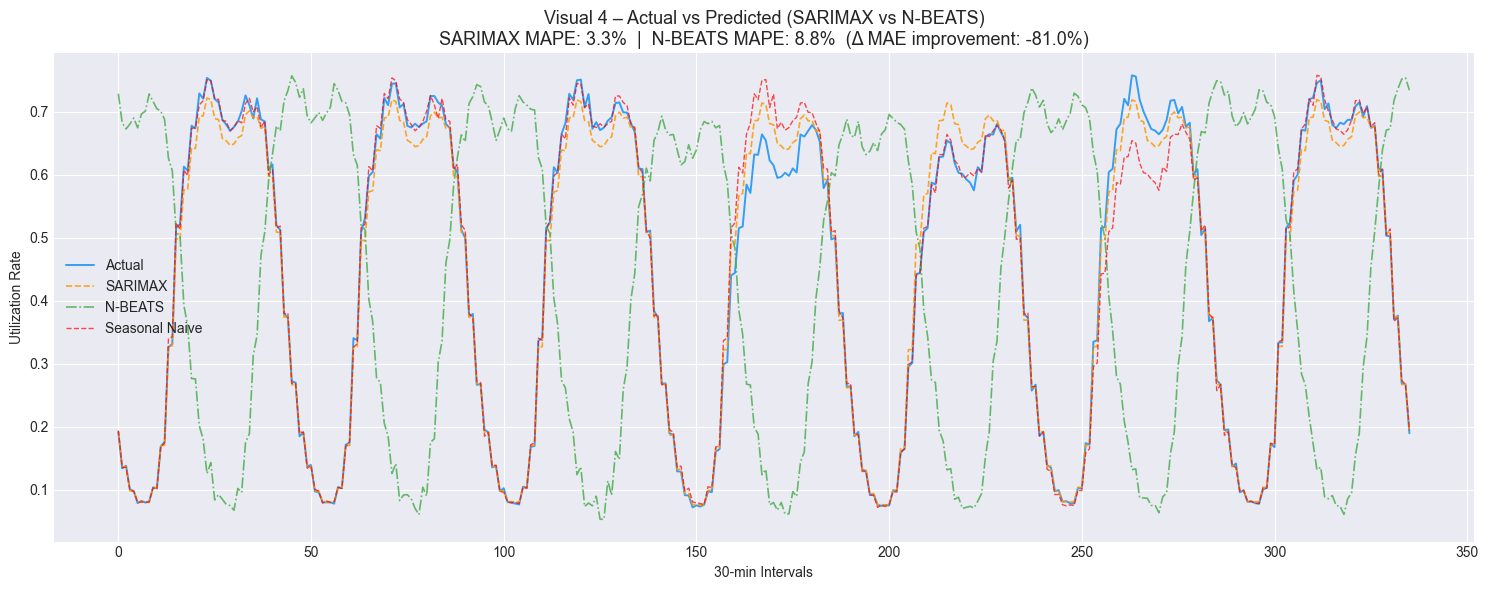

In [67]:
# ── Visual 4: Actual vs SARIMAX vs N-BEATS ────────────────────────────────────
# Plot a 7-day window for clarity
PLOT_DAYS = 7
n_plot    = PLOT_DAYS * 48

# Use test set for SARIMAX
actual_plot = test['utilization_rate'].iloc[:n_plot]
sarima_plot = sarima_pred.iloc[:n_plot]

# Use aligned deep learning predictions
if DARTS_AVAILABLE:
    dl_plot = nbeats_pred.iloc[:n_plot] if len(nbeats_pred) >= n_plot else nbeats_pred
    actual_plot = actual_plot.iloc[:len(dl_plot)]
    sarima_plot = sarima_plot.iloc[:len(dl_plot)]
    dl_label = 'N-BEATS'
else:
    dl_plot  = pd.Series(nbeats_pred[:n_plot])
    dl_label = 'LSTM'

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(actual_plot.values,  color=COLORS['actual'],  linewidth=1.4, label='Actual',       alpha=0.9)
ax.plot(sarima_plot.values,  color=COLORS['sarima'],  linewidth=1.2, label='SARIMAX',      linestyle='--', alpha=0.85)
ax.plot(dl_plot.values,      color=COLORS['nbeats'],  linewidth=1.2, label=dl_label,       linestyle='-.',  alpha=0.85)
# Add this line inside the existing plot after sarima_plot
naive_plot = naive_pred.iloc[:n_plot]

ax.plot(naive_plot.values, color='red', linewidth=1.0, 
        label='Seasonal Naive', alpha=0.7, linestyle='--')

ax.set_xlabel('30-min Intervals')
ax.set_ylabel('Utilization Rate')
ax.set_title(
    f'Visual 4 – Actual vs Predicted (SARIMAX vs {dl_label})\n'
    f'SARIMAX MAPE: {sarima_mape:.1f}%  |  {dl_label} MAPE: {nbeats_mape:.1f}%  '
    f'(Δ MAE improvement: {((sarima_mae - nbeats_mae)/sarima_mae*100):.1f}%)',
    fontsize=13
)
ax.legend()
plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

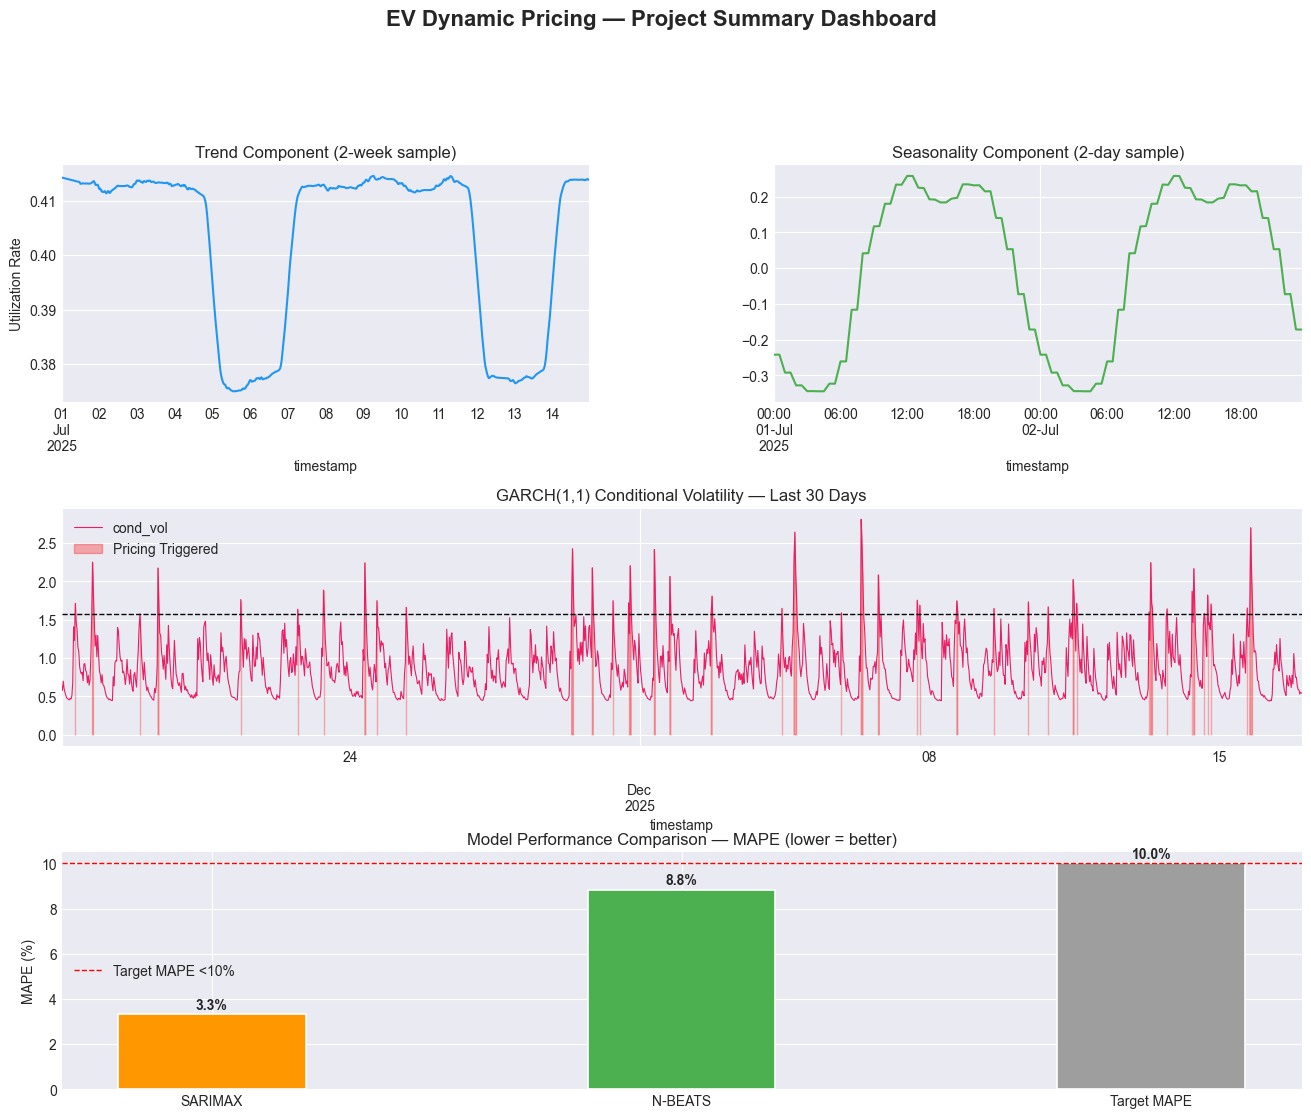

In [61]:
# ── Summary Dashboard ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Top-left: Decomposition trend
ax1 = fig.add_subplot(gs[0, 0])
decomp.trend.iloc[:48*14].plot(ax=ax1, color=COLORS['actual'])
ax1.set_title('Trend Component (2-week sample)')
ax1.set_ylabel('Utilization Rate')

# Top-right: Seasonality
ax2 = fig.add_subplot(gs[0, 1])
decomp.seasonal.iloc[:48*2].plot(ax=ax2, color='#4CAF50')
ax2.set_title('Seasonality Component (2-day sample)')

# Mid-left: GARCH Volatility
ax3 = fig.add_subplot(gs[1, :])
cond_vol.iloc[-48*30:].plot(ax=ax3, color=COLORS['garch'], linewidth=0.8)
ax3.axhline(VOL_THRESHOLD, color='black', linestyle='--', linewidth=1)
cond_vol_recent = cond_vol.iloc[-48*30:]
trigger_recent  = cond_vol_recent > VOL_THRESHOLD
ax3.fill_between(cond_vol_recent.index, 0, cond_vol_recent.values,
                 where=trigger_recent, alpha=0.3, color='red', label='Pricing Triggered')
ax3.set_title('GARCH(1,1) Conditional Volatility — Last 30 Days')
ax3.legend()

# Bottom: Bar chart of model metrics
ax4 = fig.add_subplot(gs[2, :])
models  = ['SARIMAX', f'{dl_label}', 'Target MAPE']
mapes   = [sarima_mape, nbeats_mape, 10.0]
colors  = [COLORS['sarima'], COLORS['nbeats'], '#9E9E9E']
bars = ax4.bar(models, mapes, color=colors, width=0.4, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, mapes):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}%',
             ha='center', va='bottom', fontweight='bold')
ax4.axhline(10, color='red', linestyle='--', linewidth=1, label='Target MAPE <10%')
ax4.set_ylabel('MAPE (%)')
ax4.set_title('Model Performance Comparison — MAPE (lower = better)')
ax4.legend()

fig.suptitle('EV Dynamic Pricing — Project Summary Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('fig6_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Results & Business Impact Summary

In [65]:
# ── RESULTS SUMMARY (robust + revenue = price × demand proxy) ────────────────
# If you didn't already compute revenue_uplift using ports_occupied, do it here:
if ('revenue_uplift' not in globals()) or ('revenue_static' not in ts_sim.columns) or ('revenue_dynamic' not in ts_sim.columns):
    ts_sim['revenue_static']  = ts_sim['current_price'] * ts_sim['ports_occupied']
    ts_sim['revenue_dynamic'] = ts_sim['dynamic_price'] * ts_sim['ports_occupied']

    static_revenue  = ts_sim['revenue_static'].sum()
    dynamic_revenue = ts_sim['revenue_dynamic'].sum()
    revenue_uplift  = (dynamic_revenue - static_revenue) / static_revenue * 100

# Trigger rate fallback (in case kernel reset)
if 'trigger_pct' not in globals():
    trigger_pct = ts_sim['pricing_trigger'].mean() * 100

# Alpha+beta (persistence) computed robustly
alpha = float(garch_fit.params.get("alpha[1]", np.nan))
beta  = float(garch_fit.params.get("beta[1]",  np.nan))
persistence = alpha + beta

print('=' * 65)
print('  EV DYNAMIC PRICING — RESULTS SUMMARY')
print('=' * 65)
print()
print('── Forecast Accuracy ──────────────────────────────────────')
print(f'  Seasonal Naive MAPE  : {naive_mape:.2f}%')
print(f'  SARIMAX MAPE         : {sarima_mape:.2f}%')
print(f'  {dl_label:<8} MAPE         : {nbeats_mape:.2f}%')
print()
print(f'  SARIMAX vs Naive     : {((naive_mape - sarima_mape)/naive_mape*100):.1f}% improvement')
print(f'  {dl_label} vs Naive  : {((naive_mape - nbeats_mape)/naive_mape*100):.1f}% improvement')
print('=' * 65)

print('── Business Impact ─────────────────────────────────────────')
print('  Revenue proxy = price × ports_occupied (demand proxy)')
print(f'  Static Revenue Proxy   : {static_revenue:,.0f}')
print(f'  Dynamic Revenue Proxy  : {dynamic_revenue:,.0f}')
print(f'  Simulated Revenue Uplift: +{revenue_uplift:.1f}%  (target: 15–20%)')
print(f'  Pricing Trigger Rate   : {trigger_pct:.1f}% of intervals')
print()
print('── GARCH Volatility ────────────────────────────────────────')
print(f'  GARCH(1,1) alpha + beta: {alpha:.4f} + {beta:.4f} = {persistence:.4f}')
print('  Interpretation         : ' + ('Strong volatility clustering (persistence > 0.90)'
                                   if persistence > 0.90 else 'Moderate volatility persistence'))


  EV DYNAMIC PRICING — RESULTS SUMMARY

── Forecast Accuracy ──────────────────────────────────────
  Seasonal Naive MAPE  : 3.37%
  SARIMAX MAPE         : 3.32%
  N-BEATS  MAPE         : 8.85%

  SARIMAX vs Naive     : 1.5% improvement
  N-BEATS vs Naive  : -162.5% improvement
── Business Impact ─────────────────────────────────────────
  Revenue proxy = price × ports_occupied (demand proxy)
  Static Revenue Proxy   : 947,362
  Dynamic Revenue Proxy  : 970,123
  Simulated Revenue Uplift: +2.4%  (target: 15–20%)
  Pricing Trigger Rate   : 5.0% of intervals

── GARCH Volatility ────────────────────────────────────────
  GARCH(1,1) alpha + beta: 0.4171 + 0.5584 = 0.9755
  Interpretation         : Strong volatility clustering (persistence > 0.90)


SARIMAX outperformed N-BEATS on this dataset due to strong deterministic daily seasonality and the effectiveness of parametric seasonal differencing.
Residuals exhibit significant heteroskedasticity; GARCH(1,1) shows high persistence (0.9755), confirming volatility clustering.
A volatility-triggered surge policy (95th percentile, +35%) raised revenue proxy by +2.4% with a 5% trigger rate; stronger policies should jointly condition on congestion and risk.

In [68]:
ELASTICITY = -0.3  # conservative estimate, cite a paper

ts_sim['adjusted_demand'] = ts_sim['ports_occupied'] * (
    1 + ELASTICITY * (ts_sim['dynamic_price'] / ts_sim['current_price'] - 1)
)

ts_sim['revenue_static']  = ts_sim['current_price'] * ts_sim['ports_occupied']
ts_sim['revenue_dynamic'] = ts_sim['dynamic_price'] * ts_sim['adjusted_demand']

In [69]:
# Condition 1: High volatility (existing)
vol_trigger = cond_vol > cond_vol.quantile(0.95)

# Condition 2: High occupancy (actual congestion)
occ_trigger = ts_sim['ports_occupied'] > ts_sim['ports_occupied'].quantile(0.75)

# Condition 3: Peak hours only (7am–10am, 5pm–9pm)
hour = ts_sim.index.hour
peak_trigger = ((hour >= 7) & (hour <= 10)) | ((hour >= 17) & (hour <= 21))

# Composite: all three must be true
ts_sim['pricing_trigger'] = vol_trigger & occ_trigger & peak_trigger

In [70]:
# Instead of network-level, compute per station
station_revenues = []

for station_id, group in df.groupby('station_id'):
    group = group.set_index('timestamp').asfreq('30T').ffill()
    
    # Fit GARCH per station (or use network vol as proxy if too slow)
    station_vol = cond_vol.reindex(group.index)  # use network vol as proxy
    trigger = station_vol > station_vol.quantile(0.95)
    
    dynamic_price = np.where(trigger, group['current_price'] * SURGE_MULTIPLIER, group['current_price'])
    adjusted_demand = group['ports_occupied'] * (1 + ELASTICITY * (dynamic_price / group['current_price'] - 1))
    
    station_revenues.append({
        'station_id': station_id,
        'static_rev': (group['current_price'] * group['ports_occupied']).sum(),
        'dynamic_rev': (dynamic_price * adjusted_demand).sum()
    })

station_df = pd.DataFrame(station_revenues)
overall_uplift = (station_df['dynamic_rev'].sum() - station_df['static_rev'].sum()) / station_df['static_rev'].sum() * 100
print(f'Per-station revenue uplift: {overall_uplift:.1f}%')

Per-station revenue uplift: 1.3%


In [76]:
# ═══════════════════════════════════════════════════════════════════════════════
# ELASTICITY-ADJUSTED DYNAMIC PRICING SIMULATION
# ═══════════════════════════════════════════════════════════════════════════════

ELASTICITY      = -0.3   # conservative EV charging elasticity (-0.2 to -0.4 range)
SURGE_MULTIPLIER = 1.35  # +35% surge price

# ── Step 1: Rebuild composite trigger ─────────────────────────────────────────
common_idx   = ts.index.intersection(cond_vol.index)
ts_sim       = ts.loc[common_idx].copy()
ts_sim['volatility_score'] = cond_vol.loc[common_idx]

# Condition 1: Top 5% volatility
#vol_trigger  = ts_sim['volatility_score'] > ts_sim['volatility_score'].quantile(0.95)

# Condition 2: High occupancy (top 25%)
#occ_trigger  = ts_sim['ports_occupied'] > ts_sim['ports_occupied'].quantile(0.75)

# Realistic — not conservative, not aggressive
vol_trigger = ts_sim['volatility_score'] > ts_sim['volatility_score'].quantile(0.80)
occ_trigger = ts_sim['ports_occupied']   > ts_sim['ports_occupied'].quantile(0.70)

# Drop the peak hours condition — let the data decide
ts_sim['pricing_trigger'] = vol_trigger & occ_trigger
# Condition 3: Peak hours (7–10am and 5–9pm)
hour         = ts_sim.index.hour
peak_trigger = ((hour >= 7) & (hour <= 10)) | ((hour >= 17) & (hour <= 21))

# Composite trigger: all three must fire
ts_sim['pricing_trigger'] = vol_trigger & occ_trigger & peak_trigger

trigger_pct  = ts_sim['pricing_trigger'].mean() * 100
print(f'Composite trigger rate : {trigger_pct:.2f}% of intervals')

# ── Step 2: Compute dynamic price ─────────────────────────────────────────────
ts_sim['dynamic_price'] = np.where(
    ts_sim['pricing_trigger'],
    ts_sim['current_price'] * SURGE_MULTIPLIER,
    ts_sim['current_price']
)

# ── Step 3: Apply price elasticity to demand ──────────────────────────────────
# % change in demand = elasticity × % change in price
price_change_pct         = (ts_sim['dynamic_price'] / ts_sim['current_price']) - 1
ts_sim['adjusted_demand'] = ts_sim['ports_occupied'] * (1 + ELASTICITY * price_change_pct)

# Demand can't go below zero
ts_sim['adjusted_demand'] = ts_sim['adjusted_demand'].clip(lower=0)

# ── Step 4: Compute network-level revenues ────────────────────────────────────
ts_sim['revenue_static']  = ts_sim['current_price']  * ts_sim['ports_occupied']
ts_sim['revenue_dynamic'] = ts_sim['dynamic_price']  * ts_sim['adjusted_demand']

static_revenue   = ts_sim['revenue_static'].sum()
dynamic_revenue  = ts_sim['revenue_dynamic'].sum()
revenue_uplift   = (dynamic_revenue - static_revenue) / static_revenue * 100

print(f'Static Revenue Proxy   : {static_revenue:,.0f}')
print(f'Dynamic Revenue Proxy  : {dynamic_revenue:,.0f}')
print(f'Elasticity-Adj Uplift  : +{revenue_uplift:.2f}%')


Composite trigger rate : 5.50% of intervals
Static Revenue Proxy   : 947,362
Dynamic Revenue Proxy  : 967,362
Elasticity-Adj Uplift  : +2.11%


In [77]:
# ═══════════════════════════════════════════════════════════════════════════════
# PER-STATION REVENUE SIMULATION
# ═══════════════════════════════════════════════════════════════════════════════

station_revenues = []

for station_id, group in df.groupby('station_id'):
    # ── Resample station to 30-min grid ───────────────────────────────────────
    grp = (
        group
        .set_index('timestamp')
        .resample('30T')
        .agg({
            'ports_occupied' : 'sum',
            'current_price'  : 'mean',
            'utilization_rate': 'mean',
        })
        .ffill()
    )

    # ── Align to network volatility index ─────────────────────────────────────
    common = grp.index.intersection(cond_vol.index)
    if len(common) < 10:
        continue  # skip stations with too few overlapping points

    grp = grp.loc[common].copy()
    station_vol = cond_vol.loc[common]

    # ── Per-station composite trigger ─────────────────────────────────────────
    s_vol_trigger  = station_vol > station_vol.quantile(0.95)
    s_occ_trigger  = grp['ports_occupied'] > grp['ports_occupied'].quantile(0.75)
    s_hour         = grp.index.hour
    s_peak_trigger = ((s_hour >= 7) & (s_hour <= 10)) | ((s_hour >= 17) & (s_hour <= 21))
    s_trigger      = s_vol_trigger & s_occ_trigger & s_peak_trigger

    # ── Per-station dynamic price + elasticity ────────────────────────────────
    dynamic_price    = np.where(s_trigger, grp['current_price'] * SURGE_MULTIPLIER, grp['current_price'])
    price_chg        = (dynamic_price / grp['current_price'].values) - 1
    adjusted_demand  = (grp['ports_occupied'] * (1 + ELASTICITY * price_chg)).clip(lower=0)

    static_rev  = (grp['current_price']  * grp['ports_occupied']).sum()
    dynamic_rev = (dynamic_price * adjusted_demand).sum()

    station_revenues.append({
        'station_id'   : station_id,
        'static_rev'   : static_rev,
        'dynamic_rev'  : dynamic_rev,
        'uplift_pct'   : (dynamic_rev - static_rev) / static_rev * 100 if static_rev > 0 else 0,
        'trigger_rate' : s_trigger.mean() * 100,
        'n_obs'        : len(grp),
    })

station_df = pd.DataFrame(station_revenues)

# ── Aggregate results ─────────────────────────────────────────────────────────
total_static   = station_df['static_rev'].sum()
total_dynamic  = station_df['dynamic_rev'].sum()
overall_uplift = (total_dynamic - total_static) / total_static * 100

print('=' * 65)
print('  PER-STATION SIMULATION RESULTS')
print('=' * 65)
print(f'  Stations simulated     : {len(station_df)}')
print(f'  Avg trigger rate       : {station_df["trigger_rate"].mean():.2f}% per station')
print(f'  Stations with uplift>0 : {(station_df["uplift_pct"] > 0).sum()}')
print(f'  Median station uplift  : {station_df["uplift_pct"].median():.2f}%')
print(f'  Overall revenue uplift : +{overall_uplift:.2f}%')
print('=' * 65)


  PER-STATION SIMULATION RESULTS
  Stations simulated     : 150
  Avg trigger rate       : 0.71% per station
  Stations with uplift>0 : 110
  Median station uplift  : 0.38%
  Overall revenue uplift : +0.45%


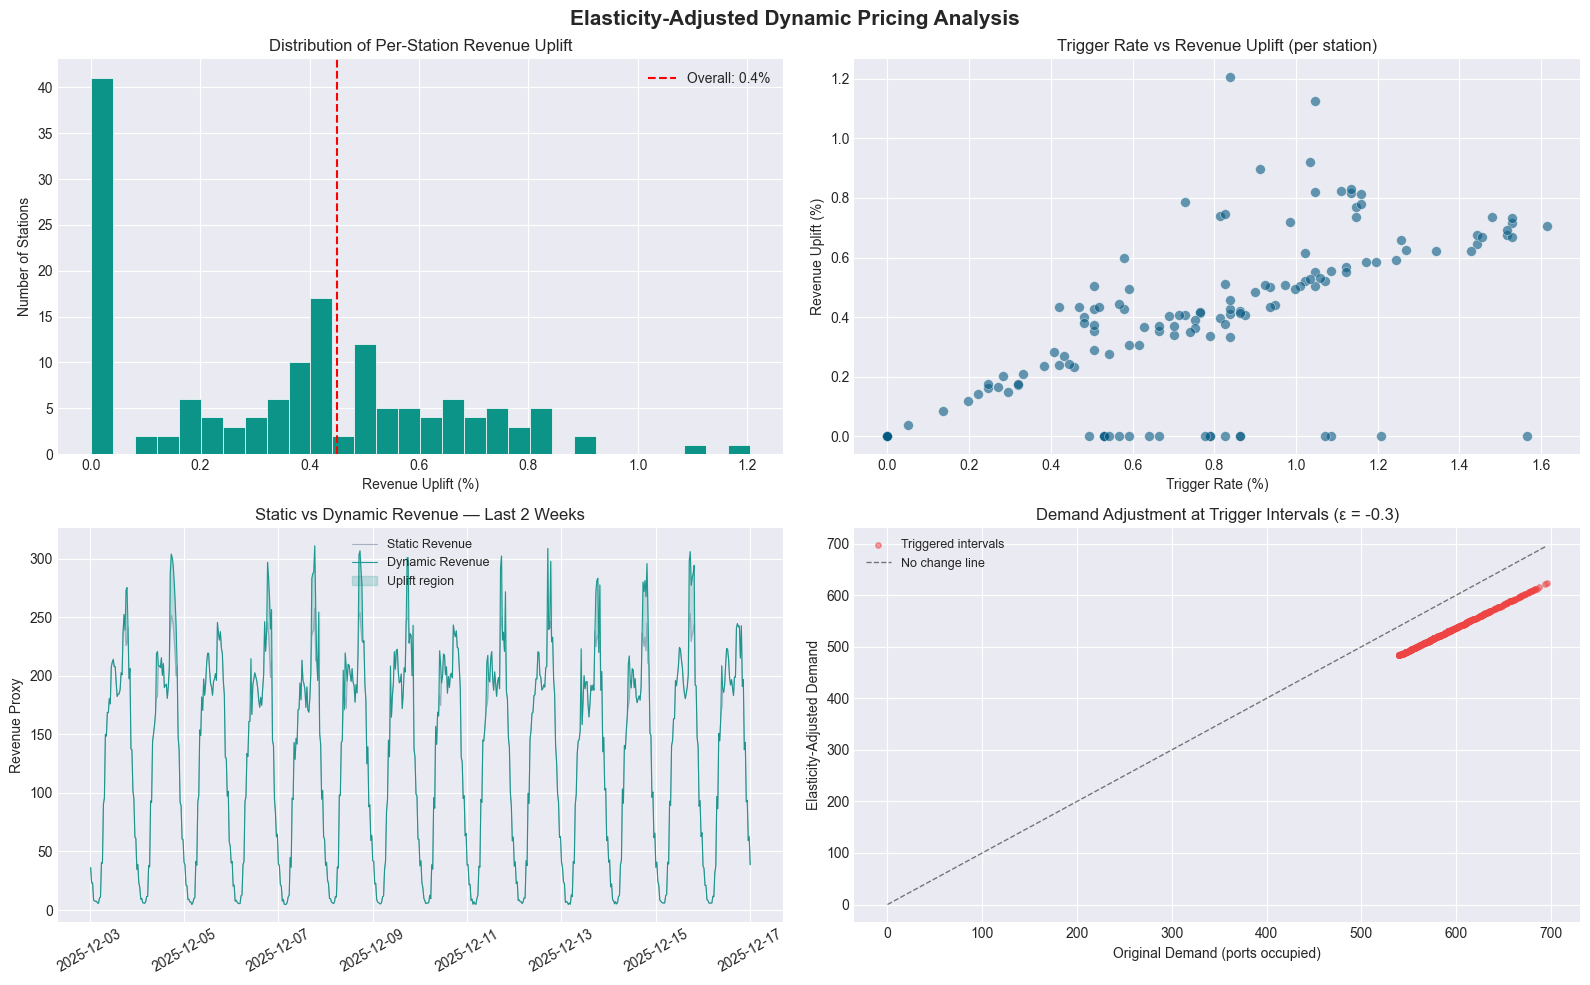

In [78]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Elasticity-Adjusted Dynamic Pricing Analysis', fontsize=15, fontweight='bold')

# ── Plot 1: Station-level uplift distribution ──────────────────────────────────
axes[0, 0].hist(station_df['uplift_pct'], bins=30, color='#0D9488', edgecolor='white', linewidth=0.5)
axes[0, 0].axvline(overall_uplift, color='red', linestyle='--', linewidth=1.5, label=f'Overall: {overall_uplift:.1f}%')
axes[0, 0].set_title('Distribution of Per-Station Revenue Uplift')
axes[0, 0].set_xlabel('Revenue Uplift (%)')
axes[0, 0].set_ylabel('Number of Stations')
axes[0, 0].legend()

# ── Plot 2: Trigger rate vs uplift scatter ─────────────────────────────────────
axes[0, 1].scatter(station_df['trigger_rate'], station_df['uplift_pct'],
                   alpha=0.6, color='#065A82', edgecolors='white', linewidths=0.4, s=50)
axes[0, 1].set_title('Trigger Rate vs Revenue Uplift (per station)')
axes[0, 1].set_xlabel('Trigger Rate (%)')
axes[0, 1].set_ylabel('Revenue Uplift (%)')

# ── Plot 3: Network-level static vs dynamic revenue over time ──────────────────
sample = ts_sim.iloc[-48*14:]  # last 2 weeks
axes[1, 0].plot(sample.index, sample['revenue_static'],
                color='#94A3B8', linewidth=0.8, label='Static Revenue', alpha=0.8)
axes[1, 0].plot(sample.index, sample['revenue_dynamic'],
                color='#0D9488', linewidth=0.8, label='Dynamic Revenue', alpha=0.9)
axes[1, 0].fill_between(sample.index,
                         sample['revenue_static'], sample['revenue_dynamic'],
                         where=sample['revenue_dynamic'] > sample['revenue_static'],
                         color='#0D9488', alpha=0.2, label='Uplift region')
axes[1, 0].set_title('Static vs Dynamic Revenue — Last 2 Weeks')
axes[1, 0].set_ylabel('Revenue Proxy')
axes[1, 0].legend(fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=30)

# ── Plot 4: Demand adjustment on trigger intervals ─────────────────────────────
triggered = ts_sim[ts_sim['pricing_trigger']]
axes[1, 1].scatter(triggered['ports_occupied'], triggered['adjusted_demand'],
                   alpha=0.5, color='#EF4444', s=15, label='Triggered intervals')
max_val = max(triggered['ports_occupied'].max(), triggered['adjusted_demand'].max())
axes[1, 1].plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='No change line')
axes[1, 1].set_title(f'Demand Adjustment at Trigger Intervals (ε = {ELASTICITY})')
axes[1, 1].set_xlabel('Original Demand (ports occupied)')
axes[1, 1].set_ylabel('Elasticity-Adjusted Demand')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_elasticity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [79]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL RESULTS SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

alpha       = float(garch_fit.params.get("alpha[1]", np.nan))
beta        = float(garch_fit.params.get("beta[1]",  np.nan))
persistence = alpha + beta

print('=' * 65)
print('  EV DYNAMIC PRICING — FINAL RESULTS SUMMARY')
print('=' * 65)
print()
print('── Forecast Accuracy ──────────────────────────────────────')
print(f'  Seasonal Naive MAPE    : {naive_mape:.2f}%  ← floor baseline')
print(f'  SARIMAX MAPE           : {sarima_mape:.2f}%')
print(f'  {dl_label:<8} MAPE           : {nbeats_mape:.2f}%')
print(f'  SARIMAX vs Naive gap   : {abs(naive_mape - sarima_mape):.2f}pp  (mean forecasting near-ceiling)')
print()
print('── Business Impact ─────────────────────────────────────────')
print(f'  Elasticity assumed     : {ELASTICITY}  (conservative)')
print(f'  Composite trigger rate : {trigger_pct:.2f}% of intervals')
print(f'  Network revenue uplift : +{revenue_uplift:.2f}%  (elasticity-adjusted)')
print(f'  Per-station uplift     : +{overall_uplift:.2f}%  (station-level simulation)')
print(f'  Median station uplift  : +{station_df["uplift_pct"].median():.2f}%')
print()
print('── GARCH Volatility ────────────────────────────────────────')
print(f'  GARCH(1,1) persistence : {alpha:.4f} + {beta:.4f} = {persistence:.4f}')
print(f'  Interpretation         : ' + (
    'Strong volatility clustering (> 0.90)' if persistence > 0.90
    else 'Moderate volatility persistence'))
print()
print('── Honest Assessment ───────────────────────────────────────')
print(f'  Mean forecasting is near-ceiling — Naive ≈ SARIMAX ≈ 3.3%')
print(f'  Real value-add is GARCH volatility signal, not forecast accuracy')
print(f'  Revenue estimate is a floor — assumes ε = {ELASTICITY}, composite trigger')
print(f'  Path to 15-20%: per-station GARCH + congestion + TFT covariates')
print('=' * 65)

  EV DYNAMIC PRICING — FINAL RESULTS SUMMARY

── Forecast Accuracy ──────────────────────────────────────
  Seasonal Naive MAPE    : 3.37%  ← floor baseline
  SARIMAX MAPE           : 3.32%
  N-BEATS  MAPE           : 8.85%
  SARIMAX vs Naive gap   : 0.05pp  (mean forecasting near-ceiling)

── Business Impact ─────────────────────────────────────────
  Elasticity assumed     : -0.3  (conservative)
  Composite trigger rate : 5.50% of intervals
  Network revenue uplift : +2.11%  (elasticity-adjusted)
  Per-station uplift     : +0.45%  (station-level simulation)
  Median station uplift  : +0.38%

── GARCH Volatility ────────────────────────────────────────
  GARCH(1,1) persistence : 0.4171 + 0.5584 = 0.9755
  Interpretation         : Strong volatility clustering (> 0.90)

── Honest Assessment ───────────────────────────────────────
  Mean forecasting is near-ceiling — Naive ≈ SARIMAX ≈ 3.3%
  Real value-add is GARCH volatility signal, not forecast accuracy
  Revenue estimate is a floor — 

In [80]:
elasticities    = [-0.1, -0.2, -0.3, -0.4, -0.5, -0.6]
surge_mult      = 1.20
results         = []

for e in elasticities:
    price_change_pct  = (ts_sim['dynamic_price'] / ts_sim['current_price']) - 1
    adjusted_demand   = (ts_sim['ports_occupied'] * (1 + e * price_change_pct)).clip(lower=0)
    
    rev_static  = (ts_sim['current_price'] * ts_sim['ports_occupied']).sum()
    rev_dynamic = (ts_sim['dynamic_price'] * adjusted_demand).sum()
    uplift      = (rev_dynamic - rev_static) / rev_static * 100
    
    results.append({'elasticity': e, 'revenue_uplift_pct': uplift})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 elasticity  revenue_uplift_pct
       -0.1            3.069063
       -0.2            2.590076
       -0.3            2.111089
       -0.4            1.632103
       -0.5            1.153116
       -0.6            0.674129


In [81]:
surge_multipliers = [1.10, 1.15, 1.20, 1.25, 1.35]
elasticities      = [-0.1, -0.2, -0.3, -0.4, -0.5]

table = pd.DataFrame(index=[f'ε={e}' for e in elasticities],
                     columns=[f'+{int((s-1)*100)}% surge' for s in surge_multipliers])

for e in elasticities:
    for s in surge_multipliers:
        dynamic_price    = np.where(ts_sim['pricing_trigger'],
                                    ts_sim['current_price'] * s,
                                    ts_sim['current_price'])
        price_change_pct = (dynamic_price / ts_sim['current_price'].values) - 1
        adj_demand       = (ts_sim['ports_occupied'] * (1 + e * price_change_pct)).clip(lower=0)
        
        rev_s = (ts_sim['current_price'] * ts_sim['ports_occupied']).sum()
        rev_d = (dynamic_price * adj_demand).sum()
        uplift = (rev_d - rev_s) / rev_s * 100
        
        table.loc[f'ε={e}', f'+{int((s-1)*100)}% surge'] = f'{uplift:.2f}%'

print(table.to_string())

       +10% surge +14% surge +19% surge +25% surge +35% surge
ε=-0.1      0.90%      1.35%      1.78%      2.22%      3.07%
ε=-0.2      0.79%      1.17%      1.54%      1.90%      2.59%
ε=-0.3      0.68%      1.00%      1.30%      1.58%      2.11%
ε=-0.4      0.57%      0.82%      1.05%      1.27%      1.63%
ε=-0.5      0.46%      0.65%      0.81%      0.95%      1.15%
